In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier

In [2]:
data = pd.DataFrame({
    'Brightness': [40, 50, 60, 10, 70, 60, 25],
    'Saturation': [20, 50, 90, 25, 70, 10, 80],
    'Class': ['Red', 'Blue', 'Blue', 'Red', 'Blue', 'Red', 'Blue']
})

data

,Brightness,Saturation,Class
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue
5,60,10,Red
6,25,80,Blue


In [3]:
print("Shape:", data.shape)

print("\nMissing Values:")
print(data.isnull().sum())

data

Shape: (7, 3)

Missing Values:
Brightness    0
Saturation    0
Class         0
dtype: int64


,Brightness,Saturation,Class
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue
5,60,10,Red
6,25,80,Blue


In [4]:
new_brightness = 45
new_saturation = 40

print(
    "New Entry =",
    (new_brightness, new_saturation)
)

New Entry = (45, 40)


In [5]:
data['Distance'] = np.sqrt(
    (data['Brightness'] - new_brightness)**2 +
    (data['Saturation'] - new_saturation)**2
)

data

,Brightness,Saturation,Class,Distance
0,40,20,Red,20.615528
1,50,50,Blue,11.180340
2,60,90,Blue,52.201533
3,10,25,Red,38.078866
4,70,70,Blue,39.051248
5,60,10,Red,33.541020
6,25,80,Blue,44.721360


In [6]:
sorted_data = data.sort_values(
    by='Distance'
)

sorted_data

,Brightness,Saturation,Class,Distance
1,50,50,Blue,11.180340
0,40,20,Red,20.615528
5,60,10,Red,33.541020
3,10,25,Red,38.078866
4,70,70,Blue,39.051248
6,25,80,Blue,44.721360
2,60,90,Blue,52.201533


In [7]:
k = 3

nearest_neighbors = sorted_data.head(k)

nearest_neighbors

,Brightness,Saturation,Class,Distance
1,50,50,Blue,11.180340
0,40,20,Red,20.615528
5,60,10,Red,33.541020


In [8]:
predicted_class = nearest_neighbors[
    'Class'
].mode()[0]

print(
    "Predicted Class using K = 3:",
    predicted_class
)

Predicted Class using K = 3: Red


In [9]:
X = data[
    ['Brightness', 'Saturation']
]

y = data['Class']

knn = KNeighborsClassifier(
    n_neighbors=3,
    metric='euclidean'
)

knn.fit(X, y)

print(
    "KNN Model Trained Successfully"
)

KNN Model Trained Successfully


In [10]:
new_entry = pd.DataFrame({
    'Brightness': [45],
    'Saturation': [40]
})

prediction = knn.predict(
    new_entry
)

print(
    "Prediction:",
    prediction[0]
)

Prediction: Red


In [11]:
distances, indices = knn.kneighbors(
    new_entry
)

print(
    "Distances:",
    distances
)

print(
    "Nearest Neighbour Indices:",
    indices
)

Distances: [[11.18033989 20.61552813 33.54101966]]
Nearest Neighbour Indices: [[1 0 5]]


In [12]:
neighbors = data.iloc[
    indices[0]
]

neighbors

,Brightness,Saturation,Class,Distance
1,50,50,Blue,11.180340
0,40,20,Red,20.615528
5,60,10,Red,33.541020


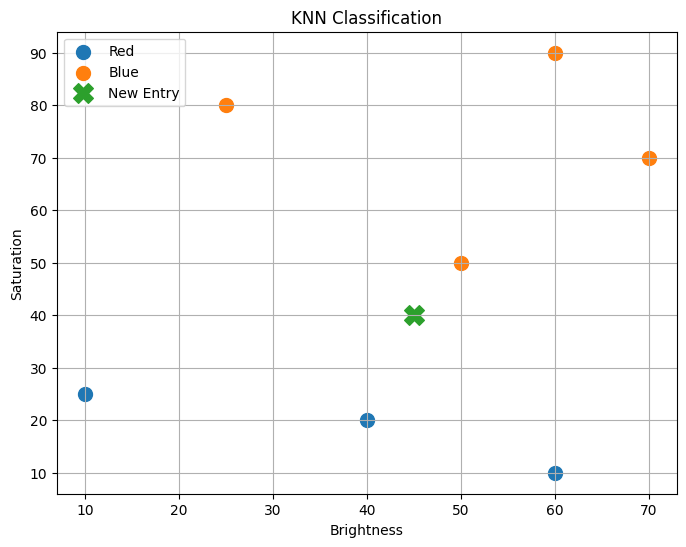

In [13]:
plt.figure(
    figsize=(8, 6)
)

for class_name in data['Class'].unique():

    subset = data[
        data['Class'] == class_name
    ]

    plt.scatter(
        subset['Brightness'],
        subset['Saturation'],
        label=class_name,
        s=100
    )

plt.scatter(
    new_brightness,
    new_saturation,
    marker='X',
    s=200,
    label='New Entry'
)

plt.xlabel(
    "Brightness"
)

plt.ylabel(
    "Saturation"
)

plt.title(
    "KNN Classification"
)

plt.legend()

plt.grid()

plt.show()